In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import warnings

# --- Global Configurations ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [39]:
# -----------------------------------------------------------------------------
# STEP 1: DATA LOADING
# -----------------------------------------------------------------------------
try:
    # Load your software defect dataset
    df = pd.read_csv('software_defect_prediction_dataset (1).csv')
    print("✓ Dataset loaded successfully.")
    print(f"Dataset Shape: {df.shape}")
except Exception as e:
    print(f"Error: {e}. Please ensure the CSV is uploaded to Colab.")

✓ Dataset loaded successfully.
Dataset Shape: (60000, 23)


In [40]:
df.head()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [41]:
df.tail()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
59995,3521,4,45,93,0.49,742,0,4,237,0,...,186,9,43,18,0.41,12,215,29,1,1
59996,4286,26,194,79,0.17,878,16,12,179,74,...,86,4,59,45,0.62,3,4,31,4,1
59997,919,46,119,42,0.03,649,1,5,194,42,...,9,1,16,18,0.93,13,207,36,5,1
59998,3127,10,120,22,0.25,971,5,11,268,141,...,38,1,34,48,0.22,0,117,6,16,1
59999,3863,27,119,18,0.58,690,16,6,196,17,...,137,9,57,39,0.83,0,102,11,11,1


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lines_of_code               60000 non-null  int64  
 1   cyclomatic_complexity       60000 non-null  int64  
 2   num_functions               60000 non-null  int64  
 3   num_classes                 60000 non-null  int64  
 4   comment_density             60000 non-null  float64
 5   code_churn                  60000 non-null  int64  
 6   developer_experience_years  60000 non-null  int64  
 7   num_developers              60000 non-null  int64  
 8   commit_frequency            60000 non-null  int64  
 9   bug_fix_commits             60000 non-null  int64  
 10  past_defects                60000 non-null  int64  
 11  test_coverage               60000 non-null  float64
 12  duplication_percentage      60000 non-null  float64
 13  avg_function_length         600


Generating 10 Exploratory Visualizations...


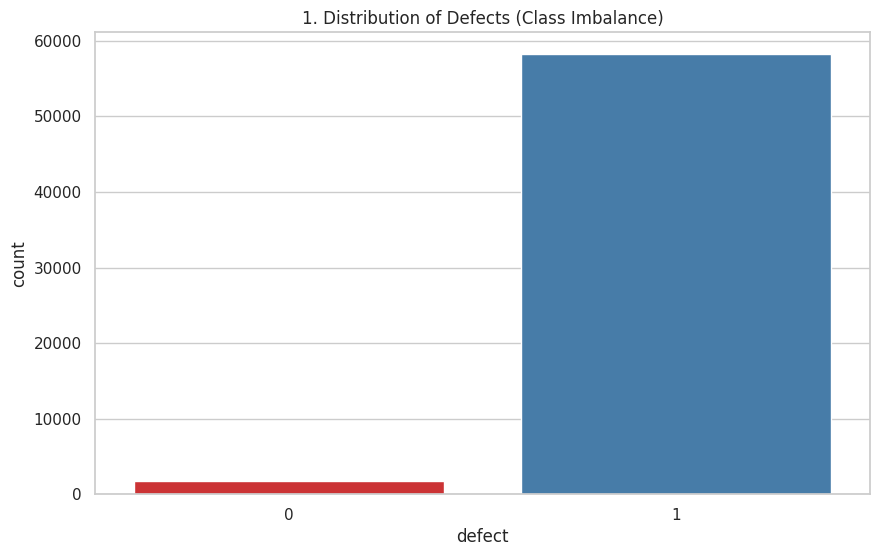

In [43]:
print("\nGenerating 10 Exploratory Visualizations...")

# 1. Target Class Imbalance
plt.figure()
sns.countplot(x='defect', data=df, palette='Set1')
plt.title('1. Distribution of Defects (Class Imbalance)')
plt.show()

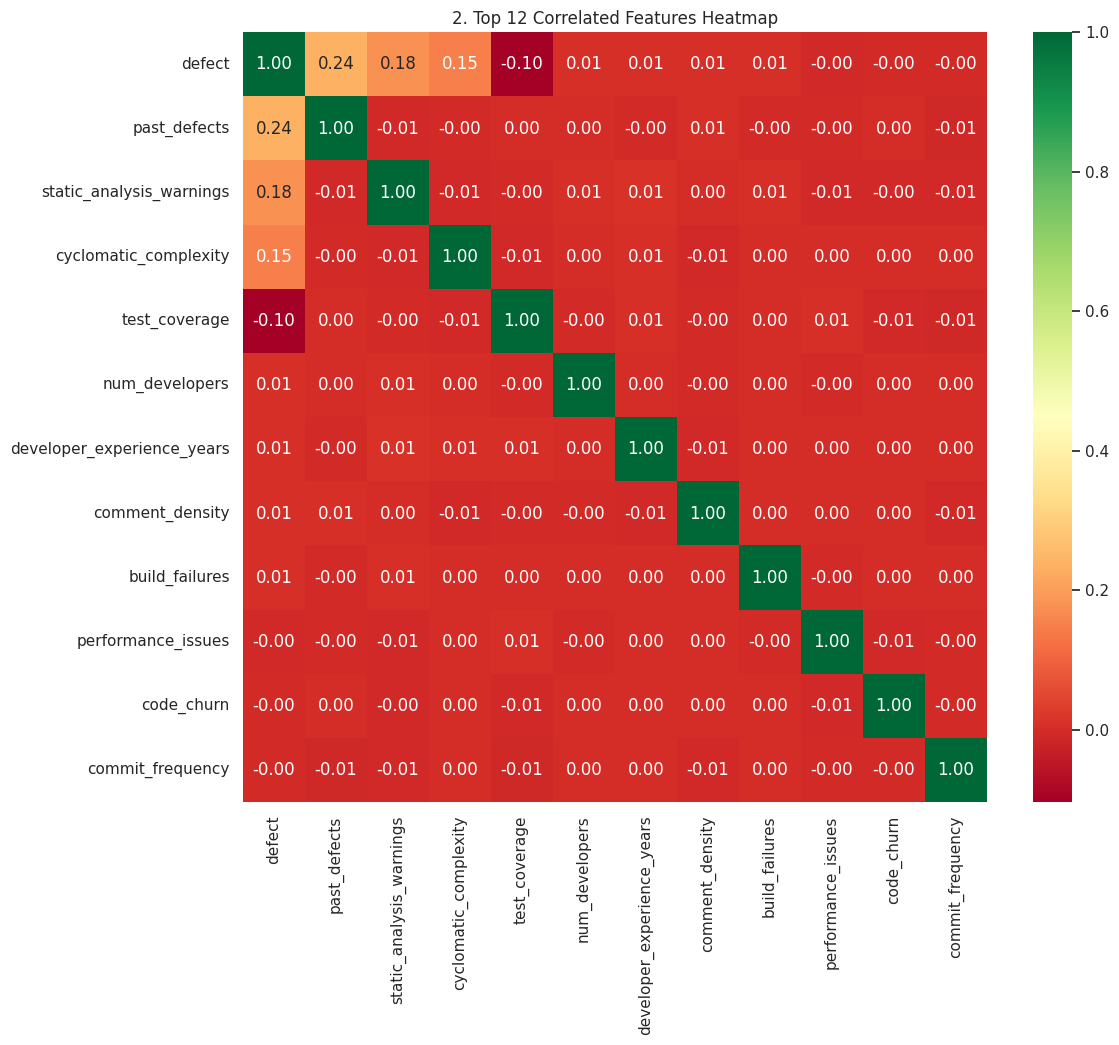

In [44]:
# 2. Correlation Heatmap (Focus on top features)
plt.figure(figsize=(12, 10))
top_corr_cols = df.corr()['defect'].abs().sort_values(ascending=False).head(12).index
sns.heatmap(df[top_corr_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('2. Top 12 Correlated Features Heatmap')
plt.show()

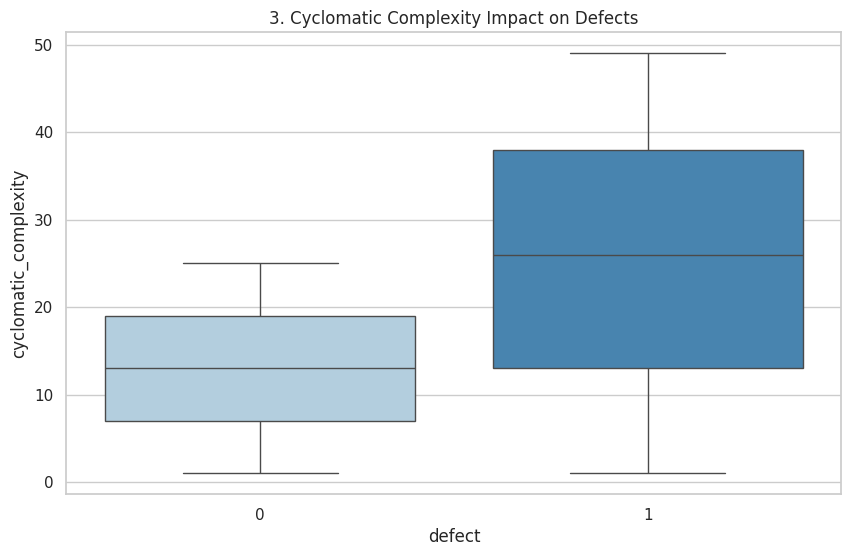

In [45]:
# 3. Cyclomatic Complexity vs. Defect (Boxplot)
plt.figure()
sns.boxplot(x='defect', y='cyclomatic_complexity', data=df, palette='Blues')
plt.title('3. Cyclomatic Complexity Impact on Defects')
plt.show()

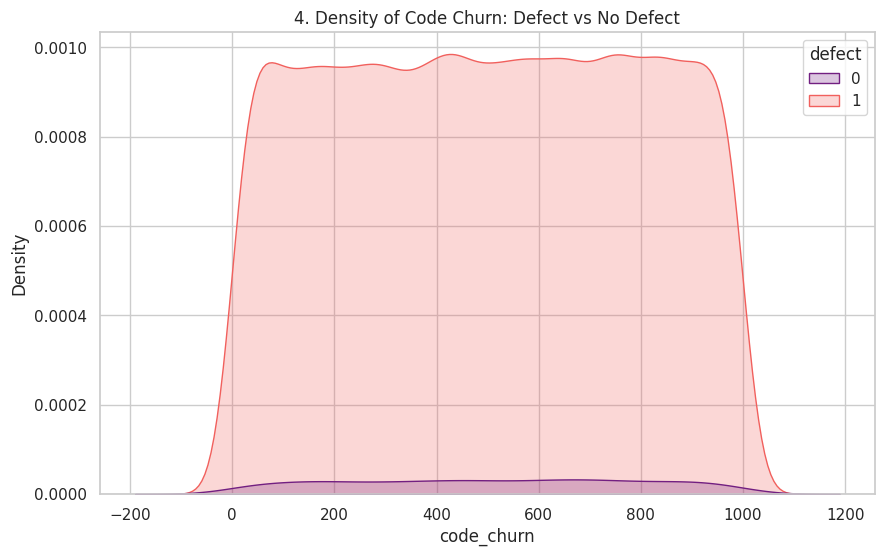

In [46]:
# 4. Code Churn Density Plot
plt.figure()
sns.kdeplot(data=df, x='code_churn', hue='defect', fill=True, palette='magma')
plt.title('4. Density of Code Churn: Defect vs No Defect')
plt.show()

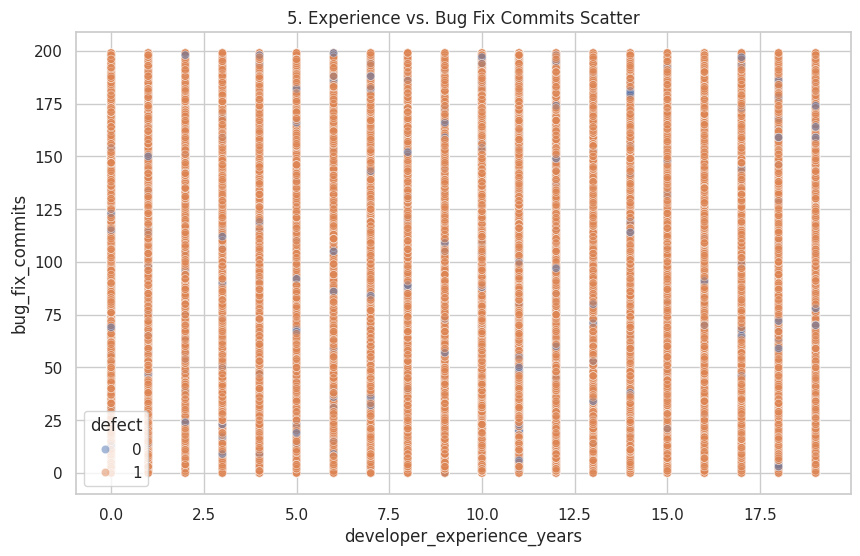

In [47]:
# 5. Developer Experience vs. Bug Fix Commits
plt.figure()
sns.scatterplot(x='developer_experience_years', y='bug_fix_commits', hue='defect', data=df, alpha=0.5)
plt.title('5. Experience vs. Bug Fix Commits Scatter')
plt.show()

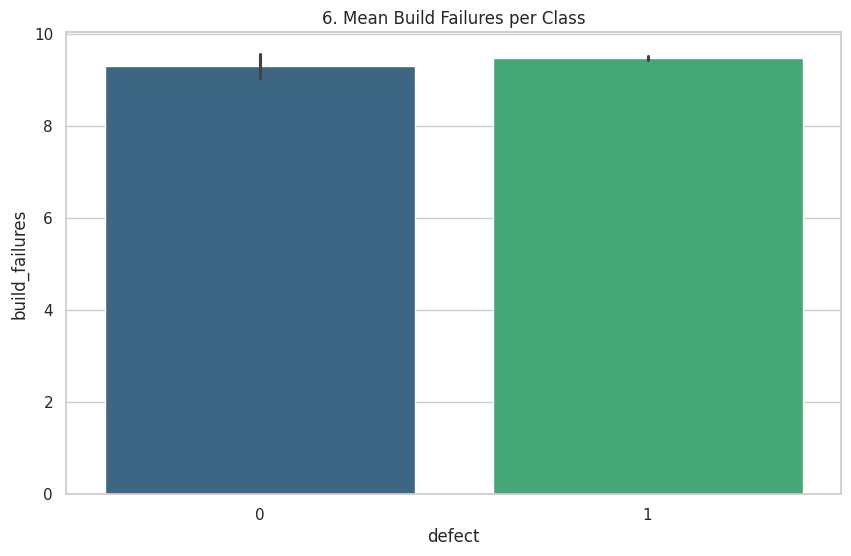

In [49]:
# 6. Build Failures Impact (Barplot)
plt.figure()
sns.barplot(x='defect', y='build_failures', data=df, palette='viridis')
plt.title('6. Mean Build Failures per Class')
plt.show()

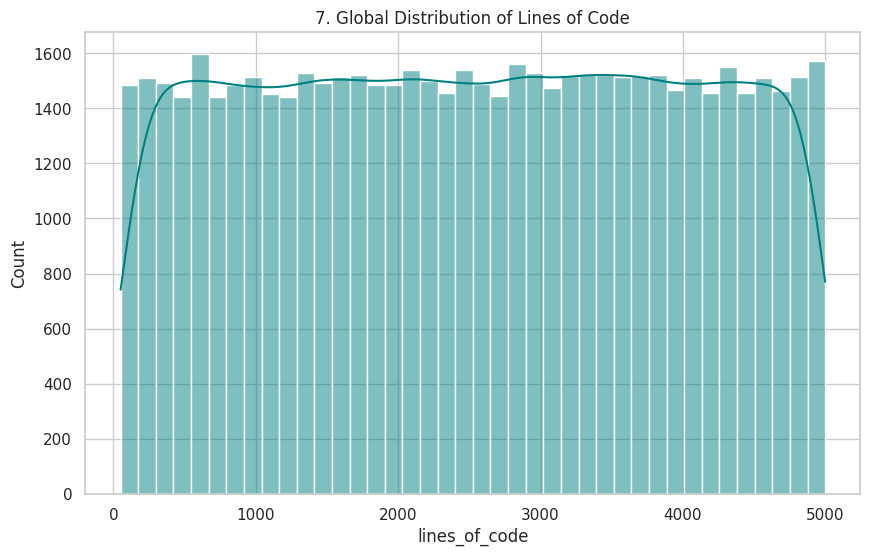

In [50]:
# 7. Lines of Code Distribution
plt.figure()
sns.histplot(df['lines_of_code'], kde=True, color='teal')
plt.title('7. Global Distribution of Lines of Code')
plt.show()

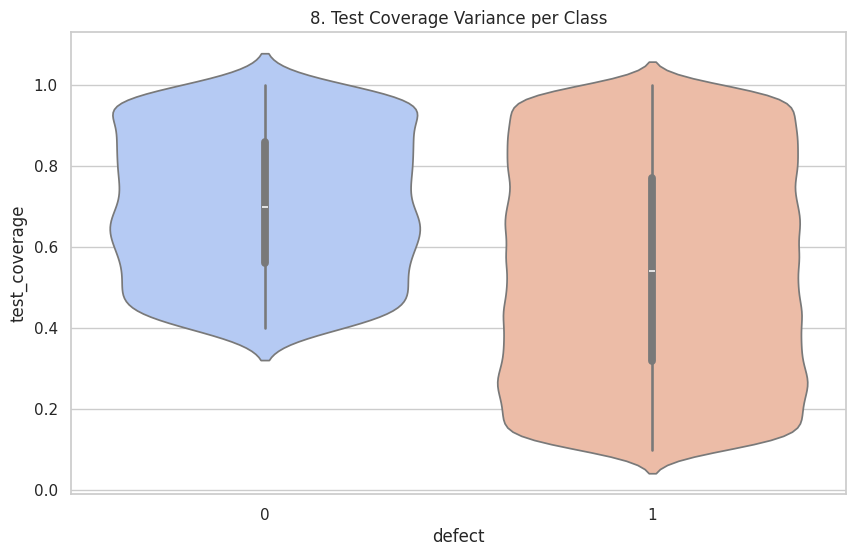

In [51]:
# 8. Test Coverage Comparison
plt.figure()
sns.violinplot(x='defect', y='test_coverage', data=df, palette='coolwarm')
plt.title('8. Test Coverage Variance per Class')
plt.show()

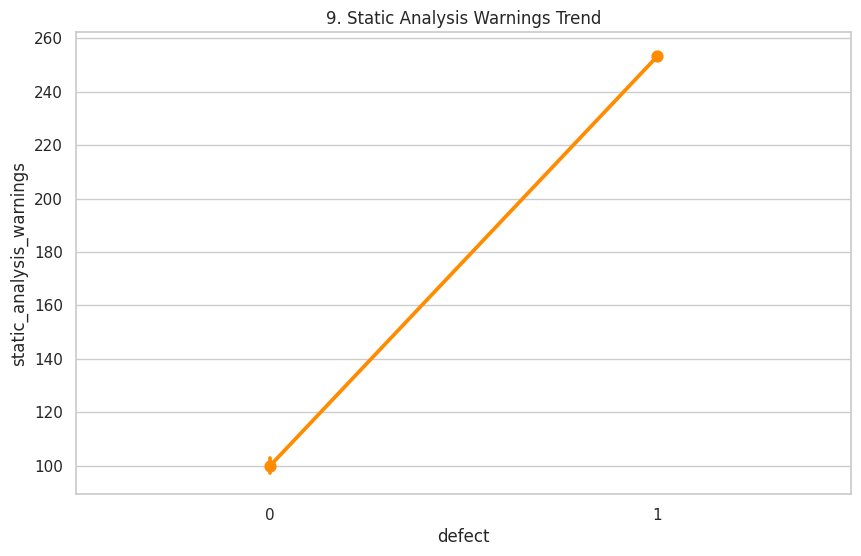

In [52]:
# 9. Static Analysis Warnings Distribution
plt.figure()
sns.pointplot(x='defect', y='static_analysis_warnings', data=df, color='darkorange')
plt.title('9. Static Analysis Warnings Trend')
plt.show()

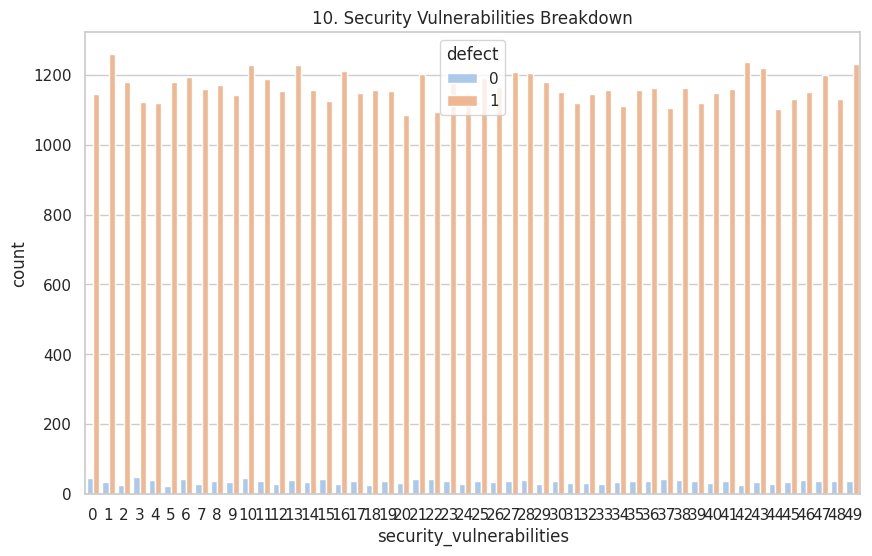

In [53]:
# 10. Security Vulnerabilities Frequency
plt.figure()
sns.countplot(x='security_vulnerabilities', hue='defect', data=df, palette='pastel')
plt.title('10. Security Vulnerabilities Breakdown')
plt.show()

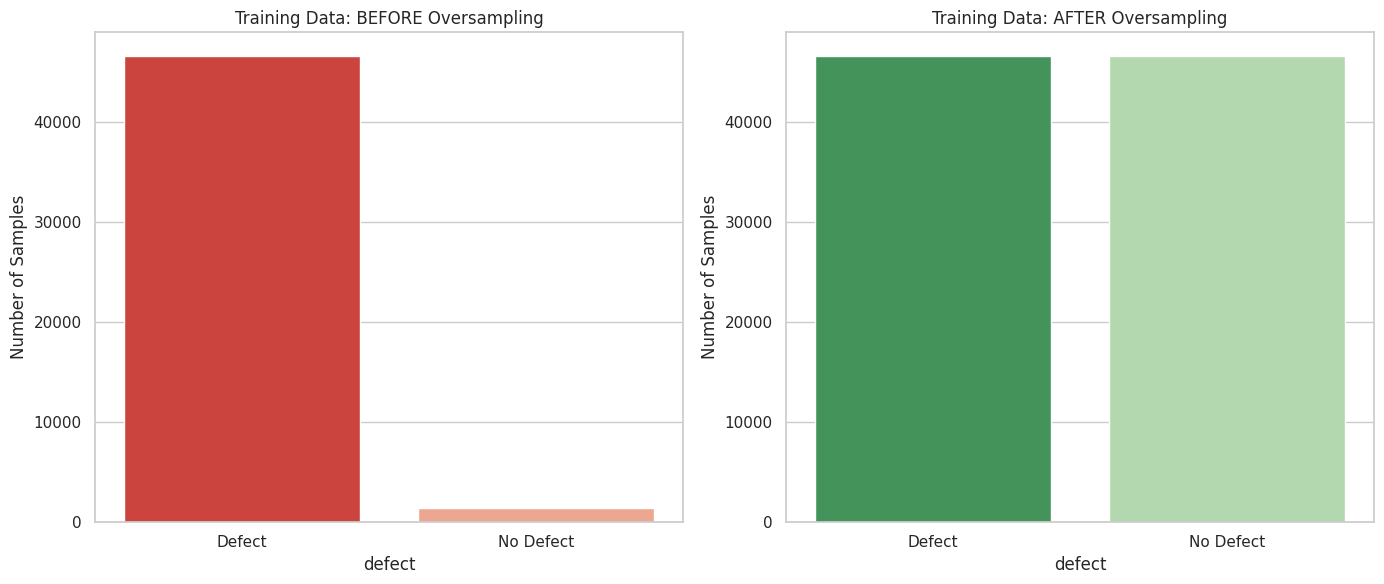

In [54]:
# -----------------------------------------------------------------------------
# STEP 3: DATA PREPARATION & OVERSAMPLING VISUALIZATION
# -----------------------------------------------------------------------------
X = df.drop('defect', axis=1)
y = df['defect']

# Split Data (Maintain class ratio)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Capture counts before oversampling
before_counts = y_train_raw.value_counts().rename({0: 'No Defect', 1: 'Defect'})

# Apply Random Oversampling to Training Set
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_raw, y_train_raw)

# Capture counts after oversampling
after_counts = pd.Series(y_train_res).value_counts().rename({0: 'No Defect', 1: 'Defect'})

# --- BEFORE vs AFTER VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=before_counts.index, y=before_counts.values, ax=axes[0], palette='Reds_r')
axes[0].set_title('Training Data: BEFORE Oversampling')
axes[0].set_ylabel('Number of Samples')

sns.barplot(x=after_counts.index, y=after_counts.values, ax=axes[1], palette='Greens_r')
axes[1].set_title('Training Data: AFTER Oversampling')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

# Scaling Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


Training and Evaluating Models...


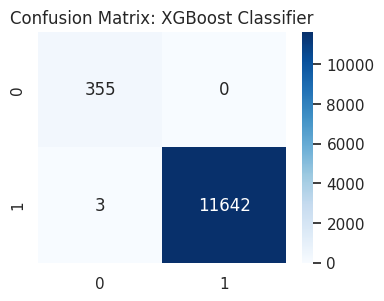

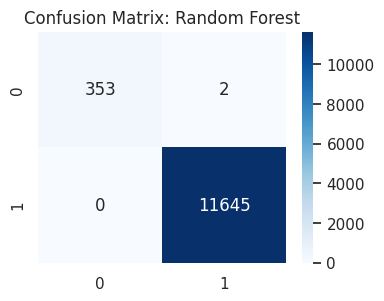

In [55]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (RANDOM FOREST & XGBOOST)
# -----------------------------------------------------------------------------
models = {
    "XGBoost Classifier": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
}

results_list = []

print("\nTraining and Evaluating Models...")
for name, model in models.items():
    model.fit(X_train, y_train_res)
    preds = model.predict(X_test_scaled)

    # Calculate Performance Metrics
    acc = accuracy_score(y_test, preds)
    pre = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1  = f1_score(y_test, preds)

    results_list.append({
        "Algorithm": name,
        "Accuracy": round(acc, 4),
        "Precision": round(pre, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

    # Display Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()


ALGORITHM PERFORMANCE RANK TABLE
               Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                           
1     XGBoost Classifier    0.9998     1.0000  0.9997    0.9999
2          Random Forest    0.9998     0.9998  1.0000    0.9999


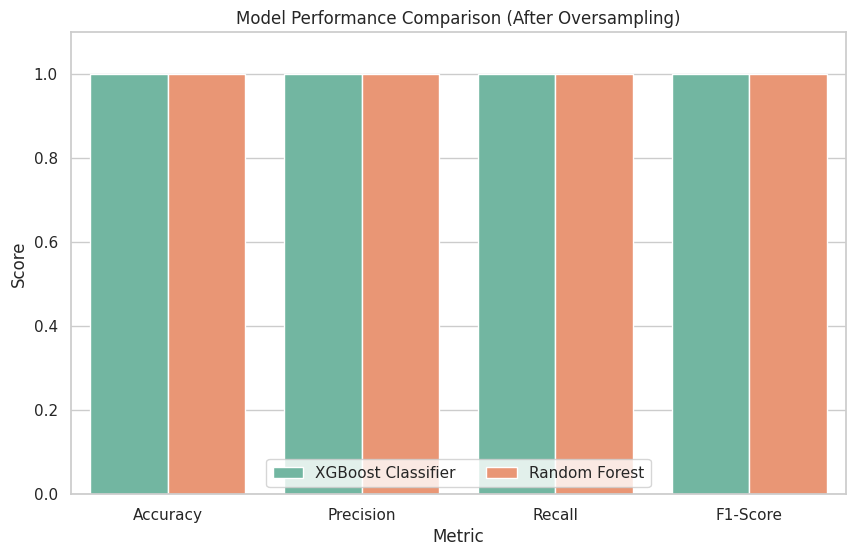

In [58]:
# -----------------------------------------------------------------------------
# STEP 5: PERFORMANCE RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results_list).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*50)
print("ALGORITHM PERFORMANCE RANK TABLE")
print("="*50)
print(rank_table)

# Multi-Metric Comparison Chart
plt.figure(figsize=(10, 6))
plot_data = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=plot_data, palette='Set2')
plt.title('Model Performance Comparison (After Oversampling)')
plt.ylim(0, 1.1)
plt.legend(loc='lower center', ncol=2)
plt.show()

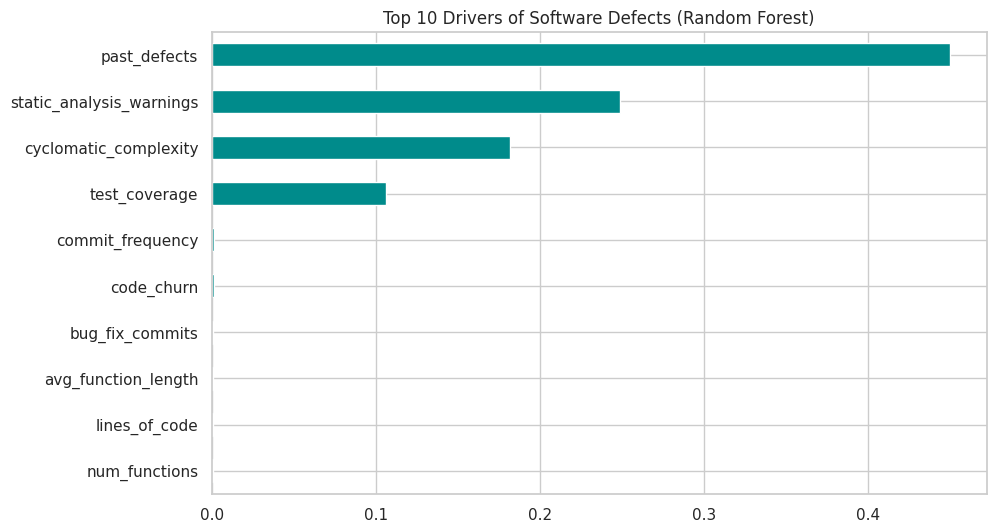

In [59]:
# Feature Importance from Best Model (Random Forest)
plt.figure()
best_model = models["Random Forest"]
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
feat_importances.plot(kind='barh', color='darkcyan')
plt.title('Top 10 Drivers of Software Defects (Random Forest)')
plt.show()

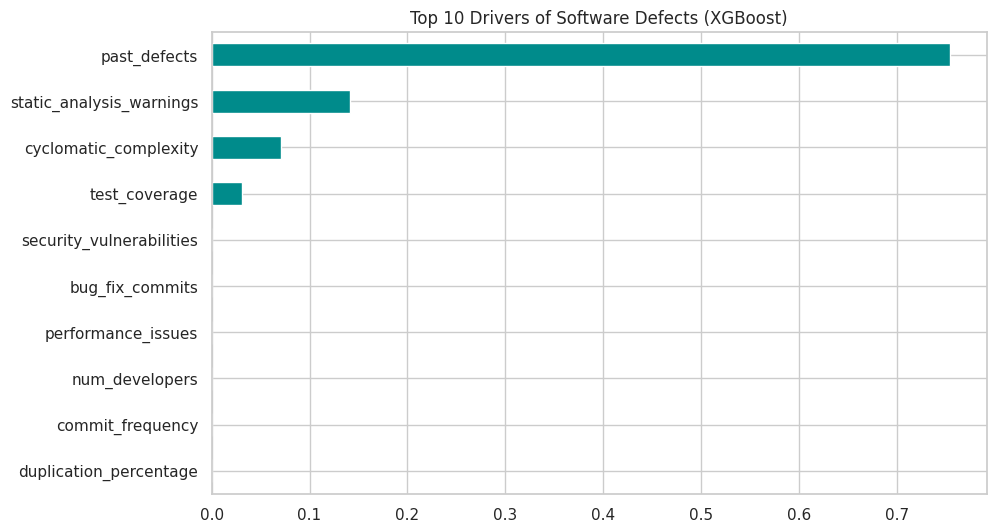

In [60]:
# Feature Importance from Best Model (XGBoost)
plt.figure()
best_model = models["XGBoost Classifier"]
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
feat_importances.plot(kind='barh', color='darkcyan')
plt.title('Top 10 Drivers of Software Defects (XGBoost)')
plt.show()